In [1]:
from config                     import config

Next

In [1]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from config import config

import importlib
import src.preprocessing as prep

importlib.reload(prep)

<module 'src.preprocessing' from 'c:\\Users\\aukha\\Python Practicum\\Titanic_kaggle\\src\\preprocessing.py'>

In [2]:

from src.data import load_data

train_df, test_df = load_data(config)






In [3]:
submission_12 = pd.read_csv('./outputs/submission_12.csv')
submission_13 = pd.read_csv('./outputs/submission_13.csv')

changed = (
    submission_12['Survived']
    != submission_13['Survived']
).sum()

print(changed)

2


In [4]:
comparison = submission_12.copy()

comparison = comparison.rename(
    columns={'Survived': 'prediction_12'}
)

comparison['prediction_13'] = submission_13['Survived']

changed = comparison[
    comparison['prediction_12']
    != comparison['prediction_13']
]

print(changed)

     PassengerId  prediction_12  prediction_13
376         1268              0              1
390         1282              1              0


In [7]:
cols = [
    'PassengerId',
    'Pclass',
    'Sex',
    'Age',
    'SibSp',
    'Parch',
    'Fare',
    'Embarked',
    # 'Title',
    # 'FamilySize',
    # 'IsAlone',
]

print(
    test_df[
        test_df['PassengerId'].isin([1268, 1282])
    ][cols]
)

     PassengerId  Pclass     Sex   Age  SibSp  Parch     Fare Embarked
376         1268       3  female  22.0      2      0   8.6625        S
390         1282       1    male  23.0      0      0  93.5000        S


In [4]:
print(
    train_df
    .groupby('SibSp')['Survived']
    .mean()
)

SibSp
0    0.345395
1    0.535885
2    0.464286
3    0.250000
4    0.166667
5    0.000000
8    0.000000
Name: Survived, dtype: float64


In [ ]:
import src.preprocessing as prep

train_df = prep.map_titles(train_df)

print(train_df["Title"].value_counts())

In [ ]:
sorted(train_df["Title"].unique())

In [ ]:
train_df, test_df = load_data(config)

print(train_df['Age'].isna().sum())
print(test_df['Age'].isna().sum())

train_df, test_df = prep.preprocess_age(
    train_df=train_df,
    test_df=test_df
)

print(train_df['Age'].isna().sum())
print(test_df['Age'].isna().sum())

In [ ]:
age_before, _ = load_data(config)

age_after, _ = prep.preprocess_age(
    train_df=age_before,
    test_df=age_before
)

check_df = age_after.loc[
    age_before['Age'].isna(),
    ['Name', 'Title', 'Age']
].copy()

check_df = check_df.rename(
    columns={'Age': 'Age_filled'}
)

print(check_df.head(50))

In [ ]:
age_before, _ = load_data(config)

age_before = prep.extract_title(age_before)
age_before = prep.map_titles(age_before)

age_before.groupby('Title')['Age'].agg(
    ['count', 'mean', 'median']
)

In [ ]:
f, ax = plt.subplots(1, 2, figsize=(16, 5))

sns.histplot(age_before['Age'], bins=30, kde=True, ax=ax[0])
ax[0].set_title('Age before imputation')

sns.histplot(age_after['Age'], bins=30, kde=True, ax=ax[1])
ax[1].set_title('Age after imputation')

plt.show()

In [ ]:
from src.data import load_data
from src.preprocessing import preprocess_age

train_df, kaggle_test_df = load_data(config)

train_cv_df, holdout_df = train_test_split(
    train_df,
    test_size=config.split.test_size,
    random_state=config.general.seed,
    shuffle=config.dataloader_params.shuffle,
    stratify=train_df['Survived']
)

train_cv_df, holdout_df = preprocess_age(
    train_df=train_cv_df,
    test_df=holdout_df
)

_, kaggle_test_df = preprocess_age(
    train_df=train_cv_df,
    test_df=kaggle_test_df
)

print(train_cv_df['Age'].isna().sum())
print(holdout_df['Age'].isna().sum())
print(kaggle_test_df['Age'].isna().sum())

Ниже черрновик для catboost

In [1]:
from sklearn.model_selection import train_test_split

from config import config
from src.data import load_data
from src.train_functions import build_pipeline


train_df, _ = load_data(config)

features = train_df.drop(columns=['Survived'])
labels = train_df['Survived']

features_train, _, labels_train, _ = train_test_split(
    features,
    labels,
    test_size=config.split.test_size,
    random_state=config.general.seed,
    shuffle=config.dataloader_params.shuffle,
    stratify=labels,
)

pipe = build_pipeline(config)

features_transformed = (
    pipe[:-1]
    .fit_transform(
        features_train,
        labels_train,
    )
)

features_transformed.head()

,Age,Fare,FamilySize,IsAlone,CabinKnown,Pclass,Sex,Title,Deck,Embarked
849,35.0,89.1042,2,0,1,1,female,Mrs,C,C
261,3.0,31.3875,7,0,0,3,male,Master,Unknown,S
752,33.0,9.5000,1,1,0,3,male,Mr,Unknown,S
537,30.0,106.4250,1,1,0,1,female,Miss,Unknown,C
432,42.0,26.0000,2,0,0,2,female,Mrs,Unknown,S


In [2]:
features_transformed.dtypes

Age           float64
Fare          float64
FamilySize      int64
IsAlone         int64
CabinKnown      int64
Pclass            str
Sex               str
Title             str
Deck              str
Embarked          str
dtype: object

In [3]:
features_transformed.isna().sum()

Age           0
Fare          0
FamilySize    0
IsAlone       0
CabinKnown    0
Pclass        0
Sex           0
Title         0
Deck          0
Embarked      0
dtype: int64

In [1]:
import os

print(f'Available CPU threads: {os.cpu_count()}')

Available CPU threads: 20


## Реализация DNN

In [34]:
from config import config
from src.data import load_data

import matplotlib.pyplot as plt

train_df, kaggle_test_df = load_data(config)

print("Train:", train_df.shape)
print("Kaggle test:", kaggle_test_df.shape)

Train: (891, 12)
Kaggle test: (418, 11)


In [35]:
import random
import numpy as np
import torch

SEED = config.general.seed

def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.use_deterministic_algorithms(True)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

In [36]:
from sklearn.model_selection import train_test_split

train_cv_df, holdout_df = train_test_split(train_df, test_size=config.split.test_size, random_state=SEED, shuffle=config.dataloader_params.shuffle, stratify=train_df["Survived"])

In [37]:
from sklearn.model_selection import train_test_split

X = train_cv_df.drop(columns="Survived")
y = train_cv_df["Survived"]

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=SEED, stratify=y)

In [38]:
X_test = holdout_df.drop(columns="Survived")
y_test = holdout_df["Survived"]

In [39]:
from sklearn.pipeline import Pipeline

from src.feature_engineering import (
    TitleExtractor,
    TitleMedianAgeImputer,
    FamilySizeCreator,
    IsAloneCreator,
    CabinKnownCreator,
    DeckExtractor
)

feature_engineering = Pipeline([
    ("title", TitleExtractor()),
    ("family_size", FamilySizeCreator()),
    ("is_alone", IsAloneCreator()),
    ("cabin_known", CabinKnownCreator()),
    ("deck", DeckExtractor()),
    ("age_imputer", TitleMedianAgeImputer()),
])

In [40]:
X_train_fe = feature_engineering.fit_transform(X_train, y_train)
X_val_fe = feature_engineering.transform(X_val)
X_test_fe = feature_engineering.transform(X_test)

In [41]:
numerical_features = [
    "Age",
    "Fare",
    "FamilySize",
    "IsAlone",
    "CabinKnown"
]

categorical_features = [
    "Pclass",
    "Sex",
    "Title",
    "Deck",
    "Embarked"
]

In [42]:
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

numerical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("one_hot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
])

preprocessor = ColumnTransformer([
    ("numerical", numerical_pipeline, numerical_features),
    ("categorical", categorical_pipeline, categorical_features)
])

In [43]:
X_train_processed = preprocessor.fit_transform(X_train_fe)
X_val_processed = preprocessor.transform(X_val_fe)
X_test_processed = preprocessor.transform(X_test_fe)

In [44]:
import numpy as np

X_train_processed = X_train_processed.astype(np.float32)
X_val_processed = X_val_processed.astype(np.float32)
X_test_processed = X_test_processed.astype(np.float32)

In [45]:
print("X_train:", X_train_processed.shape, X_train_processed.dtype)
print("X_val:", X_val_processed.shape, X_val_processed.dtype)
print("X_test:", X_test_processed.shape, X_test_processed.dtype)

X_train: (569, 27) float32
X_val: (143, 27) float32
X_test: (179, 27) float32


In [46]:
import torch

X_train_tensor = torch.tensor(X_train_processed, dtype=torch.float32)
X_val_tensor = torch.tensor(X_val_processed, dtype=torch.float32)

y_train_tensor = torch.tensor(y_train.to_numpy(), dtype=torch.long)
y_val_tensor = torch.tensor(y_val.to_numpy(), dtype=torch.long)

X_test_tensor = torch.tensor(X_test_processed, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test.to_numpy(), dtype=torch.long)

In [47]:
print(X_train_tensor.shape)
print(y_train_tensor.shape)
print(X_train_tensor.dtype)
print(y_train_tensor.dtype)

torch.Size([569, 27])
torch.Size([569])
torch.float32
torch.int64


### Создание Dataset и DataLoader

In [48]:
from torch.utils.data import DataLoader, TensorDataset

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
val_dataset = TensorDataset(X_val_tensor, y_val_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)


In [49]:
import torch
import torch.nn as nn

In [50]:
class DNN(nn.Module):
    def __init__(self, input_size, output_size=2):
        super().__init__()

        self.mlp = nn.Sequential(
            nn.Linear(input_size, 32),
            # nn.BatchNorm1d(32),
            nn.ReLU(),
            
            nn.Dropout(0.2),
            # nn.Linear(32, 32),
            # nn.BatchNorm1d(32),
            # nn.ReLU(),

            nn.Linear(32, 32),
            # nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(32, output_size),
        )

    def forward(self, x):
        out = self.mlp(x)
        return out

    

In [ ]:
# class CNN(nn.Module):
#     def __init__(self, input_size, output_size=2):
#         super().__init__()

#         self.cnn = nn.Sequential(
#             nn.Conv1d(1, 16, kernel_size=3, padding=1),
#             nn.ReLU(),
#             nn.Conv1d(16, 32, kernel_size=3, padding=1),
#             nn.ReLU(),
#             nn.Flatten(),
#             nn.Linear(32 * input_size, output_size),
#         )

#     def forward(self, x):
#         x = x.unsqueeze(1)
#         return self.cnn(x)

In [61]:
input_size = X_train_tensor.shape[1]

model = DNN(input_size=input_size, output_size=2)

In [62]:
batch_X = X_train_tensor[:32]
batch_y = y_train_tensor[:32]

test_model = DNN(input_size=X_train_tensor.shape[1], output_size=2)
logits = test_model(batch_X)

print("Признаки:", batch_X.shape)
print("Цели:", batch_y.shape)
print("Выход модели:", logits.shape)

Признаки: torch.Size([32, 27])
Цели: torch.Size([32])
Выход модели: torch.Size([32, 2])


### Инициализация

In [63]:
    #  --- Инициализация

set_seed(SEED)

EPOCHS = 200
BATCH_SIZE = 32
LEARNING_RATE = 0.0003
EARLY_STOPPING = 20
MIN_DELTA = 1e-4

generator = torch.Generator().manual_seed(SEED)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, generator=generator, num_workers=0)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
input_size = X_train_tensor.shape[1]

model = DNN(input_size=input_size, output_size=2).to(device)
loss_model = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)
# optimizer = torch.optim.SGD(model.parameters(), lr=0.003, momentum=0.9)
# optimizer = torch.optim.RMSprop(model.parameters(), lr=0.0003, momentum=0.7)
# scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS, eta_min=1e-8)
# scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="min", factor=0.5, patience=8, min_lr=1e-6)


train_loss = []
train_acc = []
val_loss = []
val_acc = []
lr_list = []

best_loss = None
best_epoch = 0
count = 0

In [64]:
    # ---- Цикл обучения


for epoch in range(EPOCHS):
    model.train()

    running_train_loss = 0
    train_correct = 0
    train_total = 0

    for x, targets in train_loader:
        x = x.to(device)
        targets = targets.to(device)

        optimizer.zero_grad()
        
        pred = model(x)
        loss = loss_model(pred, targets)
        
        loss.backward()
        optimizer.step()

        batch_size = x.size(0)

        running_train_loss += loss.item() * batch_size
        train_correct += (pred.argmax(dim=1) == targets).sum().item()
        train_total += batch_size


    mean_train_loss = running_train_loss / train_total
    running_train_acc = train_correct / train_total

    train_loss.append(mean_train_loss)
    train_acc.append(running_train_acc)

    model.eval()

    running_val_loss = 0
    val_correct = 0
    val_total = 0

    with torch.no_grad():
        for x, targets in val_loader:
            x = x.to(device)
            targets = targets.to(device)

            pred = model(x)
            loss = loss_model(pred, targets)

            batch_size = x.size(0)

            running_val_loss += loss.item() * batch_size
            val_correct += (pred.argmax(dim=1) == targets).sum().item()
            val_total += batch_size

    mean_val_loss = running_val_loss / val_total
    running_val_acc = val_correct / val_total

    val_loss.append(mean_val_loss)
    val_acc.append(running_val_acc)

    # scheduler.step(
    #     mean_val_loss
    # )

    # lr = scheduler.get_last_lr()[0]
    lr = optimizer.param_groups[0]["lr"]
    lr_list.append(lr)

    print(f"{epoch + 1:02d}/{EPOCHS} | loss: {mean_train_loss:.4f}/{mean_val_loss:.4f} | acc: {running_train_acc:.4f}/{running_val_acc:.4f} | lr: {lr:.8f}")

    if best_loss is None:
        best_loss = mean_val_loss

    if mean_val_loss < best_loss - MIN_DELTA:
        best_loss = mean_val_loss
        best_epoch = epoch + 1
        count = 0

        checkpoint = {
            "epoch": best_epoch,
            "model_state_dict": model.state_dict(),
            "best_val_loss": best_loss
        }
    else:
        count += 1
        torch.save(checkpoint, "best_model.pt")
        print(f'На эпохе - {epoch + 1}, сохранена модель со значением функции потерь на валидации - {mean_val_loss:.4f}', end='\n\n')
    
    if count >= EARLY_STOPPING:
        print(f'\033[31mОбучение остановлено на {epoch + 1} эпохе.\033[0m')
        break


print(f'Best_Val_loss: {best_loss:.4f}')

01/200 | loss: 0.6715/0.6678 | acc: 0.6415/0.6154 | lr: 0.00030000
На эпохе - 1, сохранена модель со значением функции потерь на валидации - 0.6678

02/200 | loss: 0.6657/0.6592 | acc: 0.6257/0.6224 | lr: 0.00030000
03/200 | loss: 0.6570/0.6494 | acc: 0.6362/0.6294 | lr: 0.00030000
04/200 | loss: 0.6437/0.6364 | acc: 0.6397/0.6503 | lr: 0.00030000
05/200 | loss: 0.6298/0.6212 | acc: 0.6696/0.6783 | lr: 0.00030000
06/200 | loss: 0.6147/0.6032 | acc: 0.6678/0.7063 | lr: 0.00030000
07/200 | loss: 0.5919/0.5847 | acc: 0.7170/0.7203 | lr: 0.00030000
08/200 | loss: 0.5740/0.5644 | acc: 0.7311/0.7483 | lr: 0.00030000
09/200 | loss: 0.5416/0.5444 | acc: 0.7540/0.7692 | lr: 0.00030000
10/200 | loss: 0.5291/0.5265 | acc: 0.7504/0.8252 | lr: 0.00030000
11/200 | loss: 0.4980/0.5100 | acc: 0.7821/0.8182 | lr: 0.00030000
12/200 | loss: 0.4870/0.4973 | acc: 0.7803/0.8112 | lr: 0.00030000
13/200 | loss: 0.4831/0.4870 | acc: 0.7856/0.8112 | lr: 0.00030000
14/200 | loss: 0.4717/0.4797 | acc: 0.8032/0.80

Best_Val_loss: 0.3860

SGD 0.3820 lr 0.003



### Визуализация

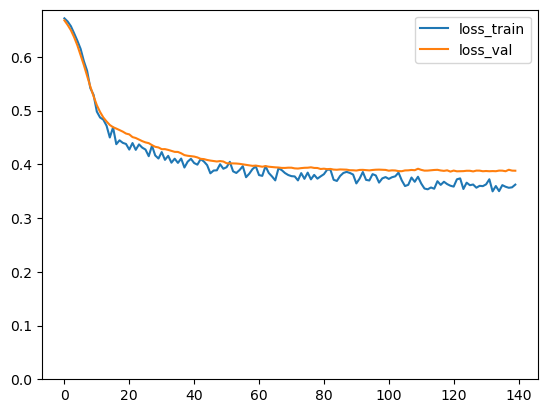

In [65]:
plt.plot(train_loss)
plt.plot(val_loss)
plt.ylim(bottom=0)
plt.legend(['loss_train', 'loss_val'])
plt.show()

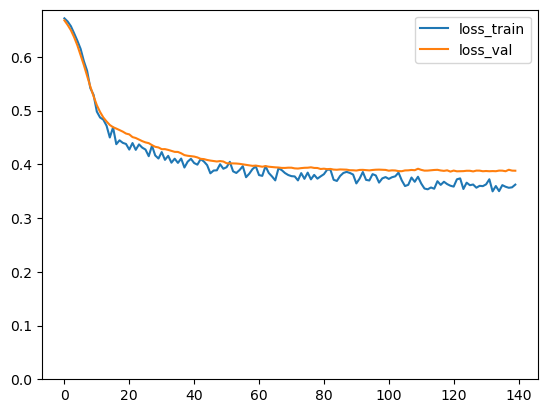

In [56]:
plt.plot(train_loss)
plt.plot(val_loss)
plt.ylim(bottom=0)
plt.legend(['loss_train', 'loss_val'])
plt.show()

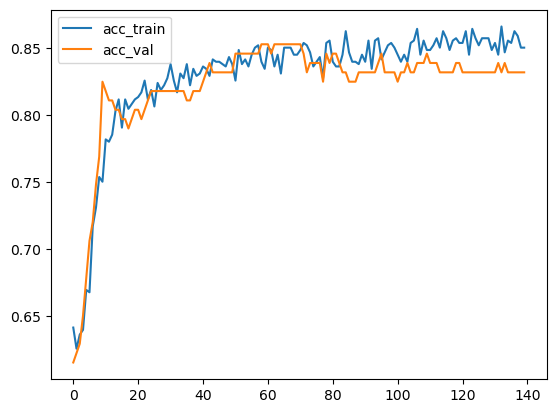

In [57]:
plt.plot(train_acc)
plt.plot(val_acc)
plt.legend(['acc_train', 'acc_val'])
plt.show()

BEST

In [58]:
# plt.plot(train_loss)
# plt.plot(val_loss)
# plt.legend(['loss_train', 'loss_val'])
# plt.show()

### Тест

In [59]:
checkpoint = torch.load("best_model.pt", map_location=device)
model.load_state_dict(checkpoint["model_state_dict"])
model.eval()

print(f"Загружена модель с эпохи {checkpoint['epoch']}, val_loss={checkpoint['best_val_loss']:.4f}")

running_test_loss = 0
test_correct = 0
test_total = 0

all_predictions = []
all_probabilities = []

with torch.no_grad():
    for x, targets in test_loader:
        x = x.to(device)
        targets = targets.to(device)

        logits = model(x)
        loss = loss_model(logits, targets)

        predictions = logits.argmax(dim=1)
        probabilities = torch.softmax(logits, dim=1)[:, 1]

        batch_size = x.size(0)

        running_test_loss += loss.item() * batch_size
        test_correct += (predictions == targets).sum().item()
        test_total += batch_size

        all_predictions.append(predictions.cpu())
        all_probabilities.append(probabilities.cpu())

mean_test_loss = running_test_loss / test_total
test_accuracy = test_correct / test_total

test_predictions = torch.cat(all_predictions).numpy()
test_probabilities = torch.cat(all_probabilities).numpy()

print(f"Test loss: {mean_test_loss:.4f} | Test accuracy: {test_accuracy:.4f}")

Загружена модель с эпохи 120, val_loss=0.3864
Test loss: 0.4133 | Test accuracy: 0.8603
